<a href="https://colab.research.google.com/github/utkarsh-a113/Regression-Models/blob/main/rice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classifications

Importing libraries

In [74]:
!pip install keras matplotlib numpy pandas tensorflow
print('\n\nAll requirements installed')



All requirements installed


Loading the imports

In [75]:
import keras
import numpy as np
import pandas as pd
import plotly.express as px
import tensorflow as tf
#adjustments
pd.options.display.max_rows=10
pd.options.display.float_format="{:.1f}".format

print("Ran them all.")

Ran them all.


Loading the dataset from kaggle

In [76]:
!pip install kaggle

In [77]:
# from google.colab import files
# files.upload()

#Importing from drive we've used kaggle to source this set i'm repeating again

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
import os
import shutil

source = "/content/drive/MyDrive/kaggle/kaggle.json"
destination = os.path.expanduser("~/.kaggle/kaggle.json")

os.makedirs(os.path.dirname(destination), exist_ok=True)

shutil.copy(source, destination)

print("kaggle.json copied successfully")


kaggle.json copied successfully


In [80]:
!kaggle datasets download -d mssmartypants/rice-type-classification -p /content/drive/MyDrive/datasets

Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification
License(s): copyright-authors
rice-type-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [81]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip from Drive
!unzip "/content/drive/MyDrive/datasets/rice-type-classification.zip" -d /content/drive/MyDrive/datasets

# Load CSV
import pandas as pd

path = "/content/drive/MyDrive/datasets/riceClassification.csv"
rice_data = pd.read_csv(path)

rice_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/datasets/rice-type-classification.zip
replace /content/drive/MyDrive/datasets/riceClassification.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/drive/MyDrive/datasets/riceClassification.csv  


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.2,64.0,0.7,4677,76.0,0.7,273.1,0.8,1.4,1
1,2,2872,74.7,51.4,0.7,3015,60.5,0.7,208.3,0.8,1.5,1
2,3,3048,76.3,52.0,0.7,3132,62.3,0.8,210.0,0.9,1.5,1
3,4,3073,77.0,51.9,0.7,3157,62.6,0.8,210.7,0.9,1.5,1
4,5,3693,85.1,56.4,0.7,3802,68.6,0.8,230.3,0.9,1.5,1


Extracting things we'll work upon

In [82]:
# @title
# Read and provide statistics on the dataset.
rice_dataset = rice_data[[
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'Eccentricity',
    'ConvexArea',
    'Extent',
    'Class',
]]

rice_dataset.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Class
count,18185.0,18185.0,18185.0,18185.0,18185.0,18185.0,18185.0,18185.0
mean,7036.5,351.6,151.7,59.8,0.9,7225.8,0.6,0.5
std,1467.2,29.5,12.4,10.1,0.0,1502.0,0.1,0.5
min,2522.0,197.0,74.1,34.4,0.7,2579.0,0.4,0.0
25%,5962.0,334.0,145.7,51.4,0.9,6125.0,0.5,0.0
50%,6660.0,353.1,153.9,55.7,0.9,6843.0,0.6,1.0
75%,8423.0,373.0,160.1,70.2,0.9,8645.0,0.7,1.0
max,10210.0,508.5,183.2,82.6,1.0,11008.0,0.9,1.0


In [83]:
# @title Overview stats

print(
    f'The shortest grain is {rice_dataset.MajorAxisLength.min():.1f}px long, '
    f'while the longest is {rice_dataset.MajorAxisLength.max():.1f}px long.'
)

print(
    f'The smallest rice grain has an area of {rice_dataset.Area.min():.1f}px², '
    f'while the largest has an area of {rice_dataset.Area.max():.1f}px².'
)

print(
    f'The largest rice grain, with a perimeter of '
    f'{rice_dataset.Perimeter.max():.1f}px, is approximately '
    f'{(rice_dataset.Perimeter.max() - rice_dataset.Perimeter.mean()) / rice_dataset.Perimeter.std():.1f} '
    f'standard deviations away from the mean perimeter '
    f'({rice_dataset.Perimeter.mean():.1f}px). '
    f'The standard deviation is {rice_dataset.Perimeter.std():.1f}px.'
)

print(
    f'This is calculated as: '
    f'({rice_dataset.Perimeter.max():.1f} - '
    f'{rice_dataset.Perimeter.mean():.1f}) / '
    f'{rice_dataset.Perimeter.std():.1f} = '
    f'{(rice_dataset.Perimeter.max() - rice_dataset.Perimeter.mean()) / rice_dataset.Perimeter.std():.1f}'
)

The shortest grain is 74.1px long, while the longest is 183.2px long.
The smallest rice grain has an area of 2522.0px², while the largest has an area of 10210.0px².
The largest rice grain, with a perimeter of 508.5px, is approximately 5.3 standard deviations away from the mean perimeter (351.6px). The standard deviation is 29.5px.
This is calculated as: (508.5 - 351.6) / 29.5 = 5.3


Exploring the dataset

In [84]:
# Create five 2D scatter plots of the features against each other,
# color-coded by class using red and blue.

for x_axis_data, y_axis_data in [
    ('Area', 'Eccentricity'),
    ('ConvexArea', 'Perimeter'),
    ('MajorAxisLength', 'MinorAxisLength'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'MajorAxisLength'),
]:
    px.scatter(
        rice_dataset,
        x=x_axis_data,
        y=y_axis_data,
        color='Class',
        color_discrete_sequence=['red', 'blue']
    ).show()

**Playing** with features

You can try multiple combinations here

In [85]:
# @title Plot three features in 3D by entering their names and running this cell

x_axis_data = 'Area'  # @param {type: "string"}
y_axis_data = 'Perimeter'  # @param {type: "string"}
z_axis_data = 'ConvexArea'  # @param {type: "string"}

px.scatter_3d(
    rice_dataset,
    x=x_axis_data,
    y=y_axis_data,
    z=z_axis_data,
    color='Class'
).show()

One take

In [86]:
# Plot major axis length, area, and eccentricity,
# with observations color-coded by class.

px.scatter_3d(
    rice_dataset,
    x='Eccentricity',
    y='Area',
    z='MajorAxisLength',
    color='Class'
).show()

Normalizing the data

In [102]:
# Calculate the Z-scores of only the input features
# and store them in a new DataFrame named normalized_dataset.

# Step 1: Separate the target column (Class)
labels = rice_dataset['Class']

# Step 2: Remove Class from features before normalization
features = rice_dataset.drop('Class', axis=1)

# Step 3: Calculate mean and standard deviation only for features
feature_mean = features.mean()
feature_std = features.std()

# Identify features with zero standard deviation and remove them
# to avoid division by zero during normalization.
features_to_keep = feature_std[feature_std != 0].index
features = features[features_to_keep]
feature_mean = feature_mean[features_to_keep]
feature_std = feature_std[features_to_keep]

# Step 4: Normalize only the feature columns
normalized_features = (
    features - feature_mean
) / feature_std

# Step 5: Add the original Class column back without normalization
normalized_dataset = normalized_features.copy()
normalized_dataset['Class'] = labels

# Display the first few rows of the normalized dataset
display(normalized_dataset.head())

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Class
0,-1.7,-2.7,-4.8,0.4,-6.4,-1.7,0.4,1
1,-2.8,-4.9,-6.2,-0.8,-6.2,-2.8,0.9,1
2,-2.7,-4.8,-6.1,-0.8,-6.0,-2.7,1.4,1
3,-2.7,-4.8,-6.0,-0.8,-5.8,-2.7,1.6,1
4,-2.3,-4.1,-5.4,-0.3,-5.4,-2.3,1.5,1


In [88]:
from sklearn.model_selection import train_test_split

input_features = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'Eccentricity',
    'ConvexArea',
    'Extent'
]

X = normalized_dataset[input_features]
y = normalized_dataset['Class']

train_features, validation_features, train_labels, validation_labels = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The values of the random weight initializations, etc, will all be the same each time the colab is run.

to fix accracy nd stuff

In [89]:
print(pd.Series(train_labels).value_counts())
print(pd.Series(validation_labels).value_counts())
print(rice_dataset['Class'].unique())

Class
1    7988
0    6560
Name: count, dtype: int64
Class
1    1997
0    1640
Name: count, dtype: int64
[1 0]


In [90]:
keras.utils.set_random_seed(42)

Labeling and spliting the data

In [91]:
# Create a column setting the Cammeo label to '1' and the Osmancik label to '0'
# then show 10 randomly selected rows.
normalized_dataset['Class_Bool'] = (
    # Returns true if class is Cammeo, and false if class is Osmancik
    normalized_dataset['Class'] == 'Cammeo'
).astype(int)
normalized_dataset.sample(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Class,Class_Bool
18056,1.6,1.9,1.9,1.0,0.1,1.7,0.3,0,0
3256,-0.8,-0.7,-0.5,-0.8,0.6,-0.8,0.2,1,0
17106,0.9,0.6,0.5,0.8,-0.4,0.9,0.5,0,0
9810,-0.4,0.5,1.3,-0.9,1.2,-0.3,1.7,1,0
9563,-1.0,-0.5,0.1,-1.3,1.2,-1.0,-1.1,1,0
9931,-1.4,-1.0,-0.4,-1.5,1.2,-1.4,-1.8,1,0
9801,-0.5,0.3,1.1,-1.0,1.2,-0.5,-1.8,1,0
6977,-0.5,-0.0,0.5,-0.8,1.0,-0.5,1.2,1,0
16677,0.7,0.4,0.2,0.7,-0.5,0.7,0.3,0,0
7517,-0.2,0.4,1.0,-0.7,1.0,-0.2,0.8,1,0


We can then randomize and partition the dataset into train, validation, and test splits, consisting of 80%, 10%, and 10% of the dataset respectively.

In [92]:
# Create indices at the 80th and 90th percentiles
number_samples = len(normalized_dataset)
index_80th = round(number_samples * 0.8)
index_90th = index_80th + round(number_samples * 0.1)

# Randomize order and split into train, validation, and test with a .8, .1, .1 split
shuffled_dataset = normalized_dataset.sample(frac=1, random_state=100)
train_data = shuffled_dataset.iloc[0:index_80th]
validation_data = shuffled_dataset.iloc[index_80th:index_90th]
test_data = shuffled_dataset.iloc[index_90th:]

# Show the first five rows of the last split
test_data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Class,Class_Bool
17948,1.2,1.1,1.2,0.8,-0.1,1.2,-0.6,0,0
1314,-0.9,-1.1,-0.9,-0.7,0.4,-0.9,1.9,1,0
16183,1.8,1.4,1.3,1.4,-0.6,1.7,-0.4,0,0
11276,-0.9,0.0,1.0,-1.5,1.5,-0.9,-0.6,1,0
1976,-0.7,-0.7,-0.6,-0.7,0.5,-0.7,-0.3,1,0


Preventing labeling leaks

In [100]:
label_columns = ['Class']

train_features = train_data.drop(columns=label_columns)
train_labels = train_data['Class'].to_numpy()
validation_features = validation_data.drop(columns=label_columns)
validation_labels = validation_data['Class'].to_numpy()
test_features = test_data.drop(columns=label_columns)
test_labels = test_data['Class'].to_numpy()

# Training the **model**

To start with, we'll train a model on Eccentricity, Major_Axis_Length, and Area.

Main Code

In [104]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from keras.callbacks import EarlyStopping

def create_model(
    input_features,
    learning_rate,
    metrics,
    l2_lambda=0.001,
    dropout_rate=0.3
) -> keras.Model:
    """Create and compile a binary classification model with regularization."""

    model_inputs = [
        keras.Input(name=feature, shape=(1,))
        for feature in input_features
    ]

    concatenated_inputs = keras.layers.Concatenate()(model_inputs)

    # Add a hidden layer with L2 regularization and ReLU activation
    hidden_layer = keras.layers.Dense(
        units=16,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(l2_lambda),
        name='hidden_layer'
    )(concatenated_inputs)

    # Add a Dropout layer
    dropout_layer = keras.layers.Dropout(dropout_rate)(hidden_layer)

    # Output layer with L2 regularization and sigmoid activation
    model_output = keras.layers.Dense(
        units=1,
        name='output_layer',
        activation='sigmoid',
        kernel_regularizer=keras.regularizers.l2(l2_lambda)
    )(dropout_layer)

    model = keras.Model(
        inputs=model_inputs,
        outputs=model_output
    )

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=learning_rate
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=metrics
    )

    return model


def train_model(
    model,
    dataset,
    labels,
    input_features,
    batch_size,
    number_epochs,
    validation_dataset=None,
    validation_labels=None
):
    """Train the model using the dataset, with optional callbacks."""

    features = {
        feature_name: np.array(dataset[feature_name])
        for feature_name in input_features
    }

    validation_data_tuple = None
    if validation_dataset is not None and validation_labels is not None:
        validation_features_dict = {
            feature_name: np.array(validation_dataset[feature_name])
            for feature_name in input_features
        }
        validation_data_tuple = (validation_features_dict, validation_labels)

    callbacks = []
    early_stopping_callback = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    callbacks.append(early_stopping_callback)

    history = model.fit(
        x=features,
        y=labels,
        batch_size=batch_size,
        epochs=number_epochs,
        verbose=1,
        validation_data=validation_data_tuple,
        callbacks=callbacks
    )

    return history


print("Defined the create_model and train_model functions.")

Defined the create_model and train_model functions.


In [105]:
# @title The first experiment settings and train the model

learning_rate = 0.001
number_epochs = 60
batch_size = 100
classification_threshold = 0.35
l2_lambda = 0.001
dropout_rate = 0.3

# Dynamically get input features from the normalized dataset (excluding the 'Class' label)
input_features = [col for col in normalized_features.columns if col != 'Class']

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy',
        threshold=classification_threshold
    ),

    keras.metrics.Precision(
        name='precision',
        thresholds=classification_threshold
    ),

    keras.metrics.Recall(
        name='recall',
        thresholds=classification_threshold
    ),

    keras.metrics.AUC(
        num_thresholds=100,
        name='auc'
    )
]


# Create the model

model = create_model(
    input_features=input_features,
    learning_rate=learning_rate,
    metrics=metrics,
    l2_lambda=l2_lambda,
    dropout_rate=dropout_rate
)


# Train the model

history = train_model(
    model=model,
    dataset=train_features,
    labels=train_labels,
    input_features=input_features,
    batch_size=batch_size,
    number_epochs=number_epochs,
    validation_dataset=validation_features,
    validation_labels=validation_labels
)


print("Model training completed successfully.")

Epoch 1/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7896 - auc: 0.8750 - loss: 0.4718 - precision: 0.7639 - recall: 0.8929 - val_accuracy: 0.9351 - val_auc: 0.9940 - val_loss: 0.1900 - val_precision: 0.8960 - val_recall: 0.9980
Epoch 2/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9422 - auc: 0.9926 - loss: 0.1564 - precision: 0.9071 - recall: 0.9969 - val_accuracy: 0.9769 - val_auc: 0.9976 - val_loss: 0.0818 - val_precision: 0.9624 - val_recall: 0.9970
Epoch 3/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9702 - auc: 0.9958 - loss: 0.0964 - precision: 0.9531 - recall: 0.9946 - val_accuracy: 0.9857 - val_auc: 0.9978 - val_loss: 0.0639 - val_precision: 0.9784 - val_recall: 0.9960
Epoch 4/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9778 - auc: 0.9972 - loss: 0.0787 - precision: 0.9666 - recall: 0.9939 - val_accuracy: 0.9868 - val_auc: 0.9982 - val_loss: 0.0591 - val_precision: 0.9803 - val_recall: 0.9960
Epoch 5/60
146/146 ━━━━━━━━━━━━━

In [97]:
rice_dataset['Class'].value_counts()
rice_dataset['Class'].unique()
train_labels[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Evaluating the model against the validation set

In [106]:
# Compare training and validation metrics

def compare_train_validation(history, validation_results, metric_names):
    print("Comparing metrics between training and validation:")

    for metric in metric_names:
        print("------")

        # Final training metric value
        train_value = history.history[metric][-1]

        # Validation metric value
        validation_value = validation_results[metric_names.index(metric)]

        print(f"Train {metric}: {train_value:.4f}")
        print(f"Validation {metric}: {validation_value:.4f}")


# Evaluate validation metrics

validation_features_dict = {
    feature_name: np.array(validation_features[feature_name])
    for feature_name in input_features
}

validation_results = model.evaluate(
    x=validation_features_dict,
    y=validation_labels,
    verbose=0
)

metric_names = ['loss', 'accuracy', 'precision', 'recall', 'auc']

compare_train_validation(
    history,
    validation_results,
    metric_names
)

Comparing metrics between training and validation:
------
Train loss: 0.0581
Validation loss: 0.0469
------
Train accuracy: 0.9853
Validation accuracy: 0.9884
------
Train precision: 0.9792
Validation precision: 0.9842
------
Train recall: 0.9944
Validation recall: 0.9950
------
Train auc: 0.9979
Validation auc: 0.9981


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


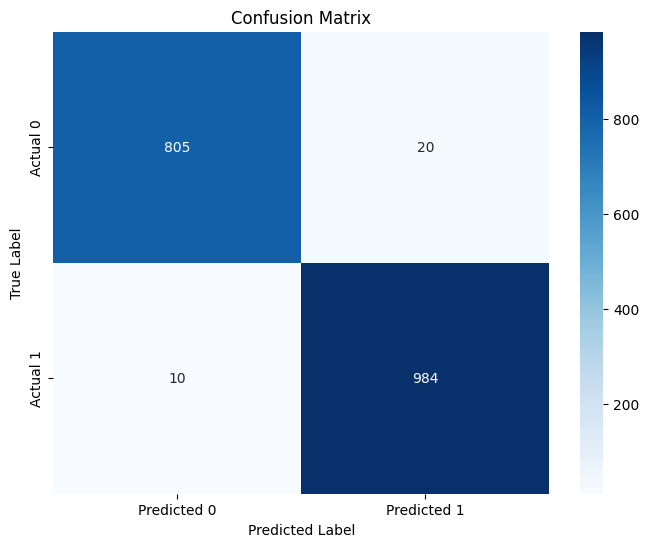

In [107]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
test_features_dict = {
    feature_name: np.array(test_features[feature_name])
    for feature_name in input_features
}
predictions = model.predict(test_features_dict)

# Convert predictions to binary labels based on the classification threshold
binary_predictions = (predictions > classification_threshold).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, binary_predictions)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


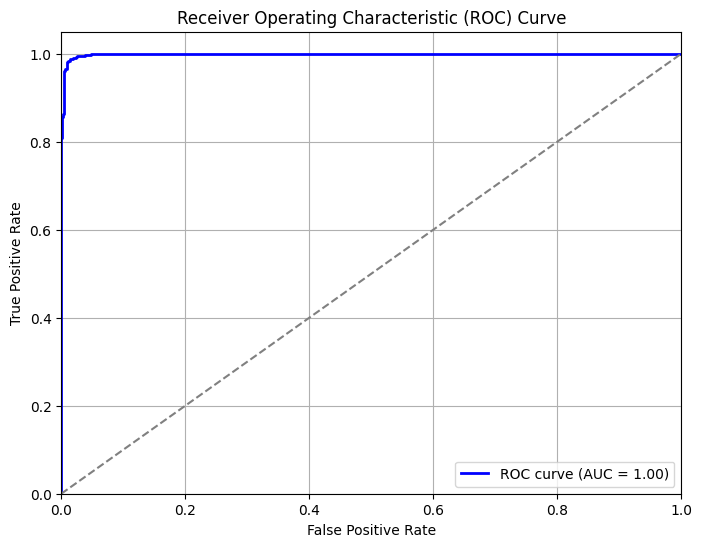

Area Under the Curve (AUC): 0.9989


In [108]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
probabilities = model.predict(test_features_dict).ravel()

# Calculate ROC curve
false_positive_rate, true_positive_rate, thresholds = roc_curve(test_labels, probabilities)
roc_auc = auc(false_positive_rate, true_positive_rate)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(false_positive_rate, true_positive_rate, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")

Now well train a model with all 7 features

In [109]:
# Features used to train the model
# Specify all input features

all_input_features = [
    'Eccentricity',
    'MajorAxisLength',
    'MinorAxisLength',
    'Area',
    'ConvexArea',
    'Perimeter',
    'Extent'
]

In [121]:
# Define settings for training using all input features

learning_rate = 0.001
number_epochs = 60
batch_size = 100
classification_threshold = 0.5


# Define metrics

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy',
        threshold=classification_threshold
    ),

    keras.metrics.Precision(
        name='precision',
        thresholds=classification_threshold
    ),

    keras.metrics.Recall(
        name='recall',
        thresholds=classification_threshold
    ),

    keras.metrics.AUC(
        num_thresholds=100,
        name='auc'
    )
]


# Create the model using all features

model_all_features = create_model(
    input_features=all_input_features,
    learning_rate=learning_rate,
    metrics=metrics
)


# Train the model

history_all_features = train_model(
    model=model_all_features,
    dataset=train_features,
    labels=train_labels,
    input_features=all_input_features,
    batch_size=batch_size,
    number_epochs=number_epochs,
    validation_dataset=validation_features,
    validation_labels=validation_labels
)


print("Model trained successfully using all input features.")

Epoch 1/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8695 - auc: 0.9569 - loss: 0.3559 - precision: 0.9177 - recall: 0.8374 - val_accuracy: 0.9785 - val_auc: 0.9974 - val_loss: 0.1589 - val_precision: 0.9652 - val_recall: 0.9970
Epoch 2/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9737 - auc: 0.9948 - loss: 0.1316 - precision: 0.9624 - recall: 0.9907 - val_accuracy: 0.9868 - val_auc: 0.9979 - val_loss: 0.0742 - val_precision: 0.9803 - val_recall: 0.9960
Epoch 3/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9816 - auc: 0.9967 - loss: 0.0871 - precision: 0.9739 - recall: 0.9932 - val_accuracy: 0.9873 - val_auc: 0.9980 - val_loss: 0.0623 - val_precision: 0.9822 - val_recall: 0.9950
Epoch 4/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9837 - auc: 0.9966 - loss: 0.0784 - precision: 0.9777 - recall: 0.9930 - val_accuracy: 0.9879 - val_auc: 0.9984 - val_loss: 0.0584 - val_precision: 0.9832 - val_recall: 0.9950
Epoch 5/60
146/146 ━━━━━━━━━━━━━

Evaluating it on this split

In [111]:
# Evaluate validation metrics for the model trained using all input features

validation_features_dict = {
    feature_name: np.array(validation_features[feature_name])
    for feature_name in all_input_features
}

validation_results_all_features = model_all_features.evaluate(
    x=validation_features_dict,
    y=validation_labels,
    verbose=0
)

metric_names = ['loss', 'accuracy', 'precision', 'recall', 'auc']

compare_train_validation(
    history_all_features,
    validation_results_all_features,
    metric_names
)

Comparing metrics between training and validation:
------
Train loss: 0.0579
Validation loss: 0.0467
------
Train accuracy: 0.9867
Validation accuracy: 0.9895
------
Train precision: 0.9845
Validation precision: 0.9881
------
Train recall: 0.9914
Validation recall: 0.9930
------
Train auc: 0.9977
Validation auc: 0.9981


In [113]:
from sklearn.metrics import classification_report

# Make predictions on the test set using the model trained with all features
test_features_dict_all_features = {
    feature_name: np.array(test_features[feature_name])
    for feature_name in all_input_features
}
predictions_all_features = model_all_features.predict(test_features_dict_all_features)

# Convert predictions to binary labels based on the classification threshold
binary_predictions_all_features = (predictions_all_features > classification_threshold).astype(int)

# Generate and print the classification report
report = classification_report(test_labels, binary_predictions_all_features)
print("Classification Report for Model with All Features:")
print(report)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Classification Report for Model with All Features:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       825
           1       0.99      0.99      0.99       994

    accuracy                           0.99      1819
   macro avg       0.99      0.99      0.99      1819
weighted avg       0.99      0.99      0.99      1819



## Cross-Validation for Model Stability

To further assess the model's stability and generalization capabilities, we will perform Stratified K-Fold Cross-Validation. This approach ensures that each fold maintains the same class distribution as the original dataset, which is crucial for binary classification problems.

In [115]:
from sklearn.model_selection import StratifiedKFold

# Prepare data for cross-validation
X_cv = normalized_dataset[all_input_features]
y_cv = normalized_dataset['Class']

# Define the number of folds
n_splits = 5 # Commonly used value

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
auc_scores = []
loss_scores = []

print(f"Performing {n_splits}-fold cross-validation...")

for fold, (train_index, test_index) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")

    # Split data for the current fold
    train_fold_features = X_cv.iloc[train_index]
    train_fold_labels = y_cv.iloc[train_index].to_numpy()
    test_fold_features = X_cv.iloc[test_index]
    test_fold_labels = y_cv.iloc[test_index].to_numpy()

    # Re-create and compile the model for the current fold
    fold_model = create_model(
        input_features=all_input_features,
        learning_rate=learning_rate,
        metrics=metrics,
        l2_lambda=l2_lambda,
        dropout_rate=dropout_rate
    )

    # Train the model for the current fold
    fold_history = train_model(
        model=fold_model,
        dataset=train_fold_features,
        labels=train_fold_labels,
        input_features=all_input_features,
        batch_size=batch_size,
        number_epochs=number_epochs,
        validation_dataset=test_fold_features, # Using test fold as validation during training for early stopping
        validation_labels=test_fold_labels
    )

    # Evaluate the model on the test set of the current fold
    test_fold_features_dict = {
        feature_name: np.array(test_fold_features[feature_name])
        for feature_name in all_input_features
    }

    results = fold_model.evaluate(
        x=test_fold_features_dict,
        y=test_fold_labels,
        verbose=0
    )

    # Store results
    loss_scores.append(results[0])
    accuracy_scores.append(results[1])
    precision_scores.append(results[2])
    recall_scores.append(results[3])
    auc_scores.append(results[4])

    print(f"Fold {fold + 1} Test Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}, Precision: {results[2]:.4f}, Recall: {results[3]:.4f}, AUC: {results[4]:.4f}")

print("\n--- Cross-Validation Summary ---")
print(f"Average Loss: {np.mean(loss_scores):.4f} (+/- {np.std(loss_scores):.4f})")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average AUC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")

Performing 5-fold cross-validation...

--- Fold 1/5 ---
Epoch 1/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9366 - auc: 0.9760 - loss: 0.3516 - precision: 0.9180 - recall: 0.9713 - val_accuracy: 0.9761 - val_auc: 0.9965 - val_loss: 0.1548 - val_precision: 0.9605 - val_recall: 0.9975
Epoch 2/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9758 - auc: 0.9946 - loss: 0.1279 - precision: 0.9633 - recall: 0.9937 - val_accuracy: 0.9852 - val_auc: 0.9988 - val_loss: 0.0698 - val_precision: 0.9788 - val_recall: 0.9945
Epoch 3/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9814 - auc: 0.9965 - loss: 0.0844 - precision: 0.9754 - recall: 0.9912 - val_accuracy: 0.9863 - val_auc: 0.9991 - val_loss: 0.0583 - val_precision: 0.9836 - val_recall: 0.9915
Epoch 4/60
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9834 - auc: 0.9971 - loss: 0.0752 - precision: 0.9782 - recall: 0.9920 - val_accuracy: 0.9874 - val_auc: 0.9992 - val_loss: 0.0548 - val_precision: 0.98

In [116]:
# Compare baseline model and all-features model
# using accuracy and AUC on validation data

print("Baseline Model vs All Features Model Comparison")

print("\nBaseline Model Evaluation:")
baseline_validation_features_dict = {
    feature_name: np.array(validation_features[feature_name])
    for feature_name in input_features
}

baseline_results = model.evaluate(
    x=baseline_validation_features_dict,
    y=validation_labels,
    verbose=0
)

print(f"Accuracy: {baseline_results[1]:.4f}")
print(f"AUC: {baseline_results[4]:.4f}")


print("\nAll Features Model Evaluation:")
all_features_validation_dict = {
    feature_name: np.array(validation_features[feature_name])
    for feature_name in all_input_features
}

all_features_results = model_all_features.evaluate(
    x=all_features_validation_dict,
    y=validation_labels,
    verbose=0
)

print(f"Accuracy: {all_features_results[1]:.4f}")
print(f"AUC: {all_features_results[4]:.4f}")

Baseline Model vs All Features Model Comparison

Baseline Model Evaluation:
Accuracy: 0.9884
AUC: 0.9981

All Features Model Evaluation:
Accuracy: 0.9895
AUC: 0.9981


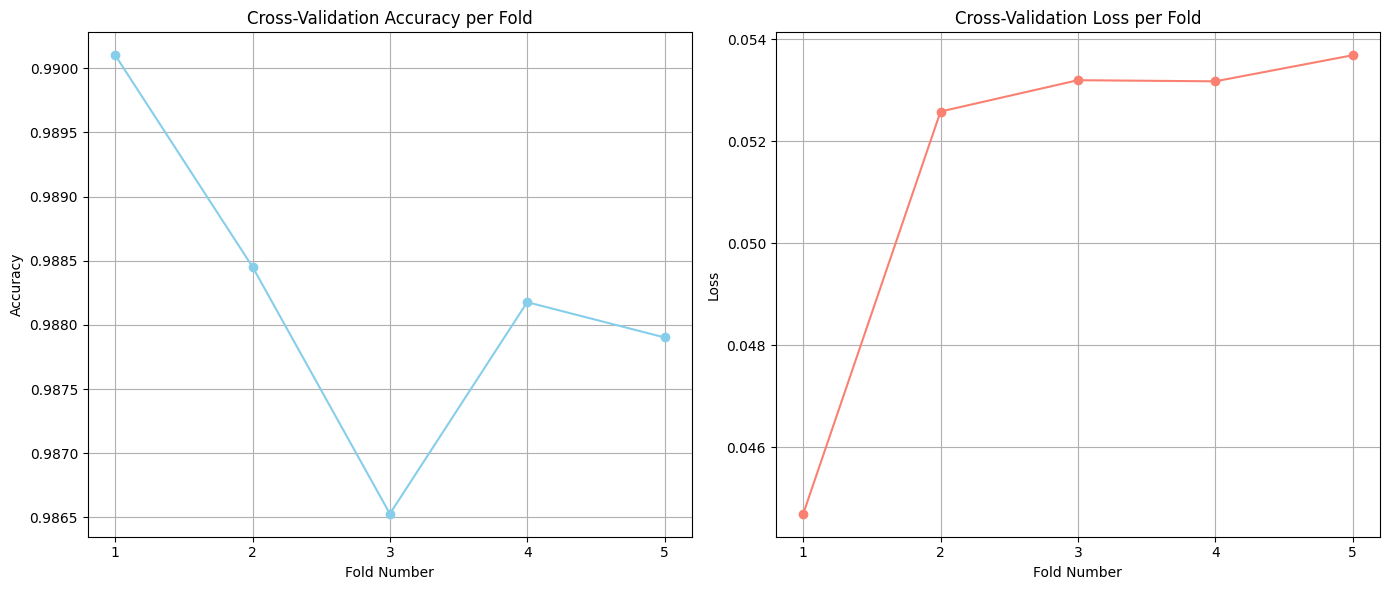

In [118]:
import matplotlib.pyplot as plt
import numpy as np

# Create fold numbers for the x-axis
folds = np.arange(1, n_splits + 1)

plt.figure(figsize=(14, 6))

# Plot Accuracy for each fold
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(folds, accuracy_scores, marker='o', linestyle='-', color='skyblue')
plt.title('Cross-Validation Accuracy per Fold')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.xticks(folds)
plt.grid(True)

# Plot Loss for each fold
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(folds, loss_scores, marker='o', linestyle='-', color='salmon')
plt.title('Cross-Validation Loss per Fold')
plt.xlabel('Fold Number')
plt.ylabel('Loss')
plt.xticks(folds)
plt.grid(True)

plt.tight_layout()
plt.show()

## Model Performance Comparison: Baseline vs. All Features

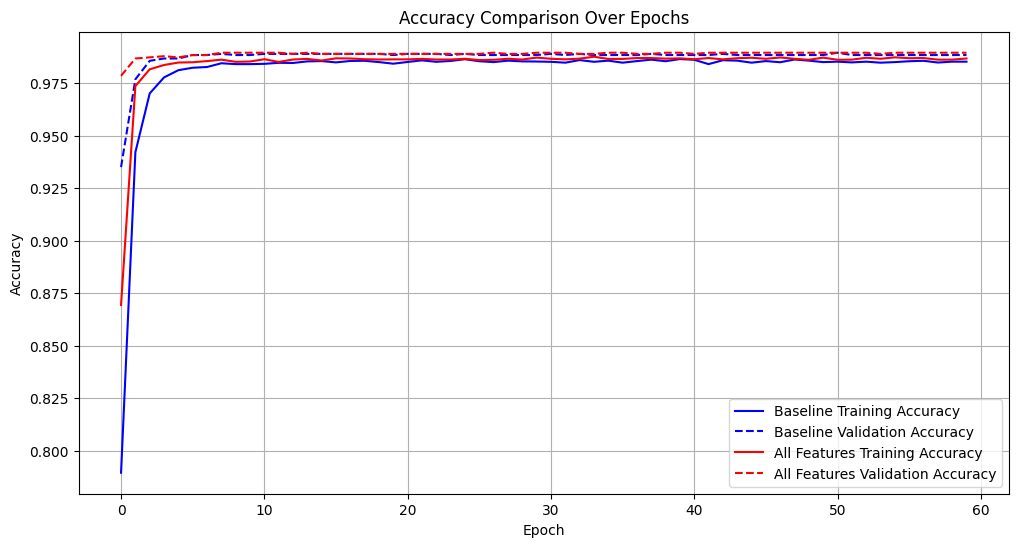

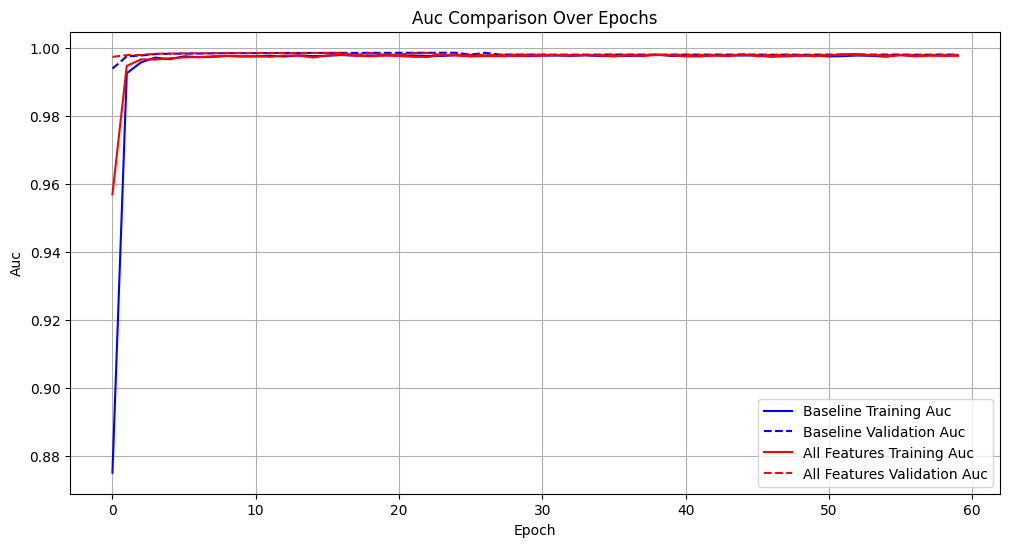

In [123]:
import matplotlib.pyplot as plt

def plot_metrics_comparison(history_baseline, history_all_features, metric_name):
    """Plots a comparison of a given metric (e.g., accuracy, auc) for both models."""

    plt.figure(figsize=(12, 6))

    # Plot training metric for baseline model
    plt.plot(
        history_baseline.history[metric_name],
        label=f'Baseline Training {metric_name.capitalize()}',
        color='blue', linestyle='-'
    )

    # Plot validation metric for baseline model
    plt.plot(
        history_baseline.history[f'val_{metric_name}'],
        label=f'Baseline Validation {metric_name.capitalize()}',
        color='blue', linestyle='--'
    )

    # Plot training metric for all features model
    plt.plot(
        history_all_features.history[metric_name],
        label=f'All Features Training {metric_name.capitalize()}',
        color='red', linestyle='-'
    )

    # Plot validation metric for all features model
    plt.plot(
        history_all_features.history[f'val_{metric_name}'],
        label=f'All Features Validation {metric_name.capitalize()}',
        color='red', linestyle='--'
    )

    plt.title(f'{metric_name.capitalize()} Comparison Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric_name.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Accuracy comparison
plot_metrics_comparison(history, history_all_features, 'accuracy')

# Plot AUC comparison
plot_metrics_comparison(history, history_all_features, 'auc')

In [122]:
print(history_all_features.history.keys())

dict_keys(['accuracy', 'auc', 'loss', 'precision', 'recall', 'val_accuracy', 'val_auc', 'val_loss', 'val_precision', 'val_recall'])


### Comparison of Precision and Recall

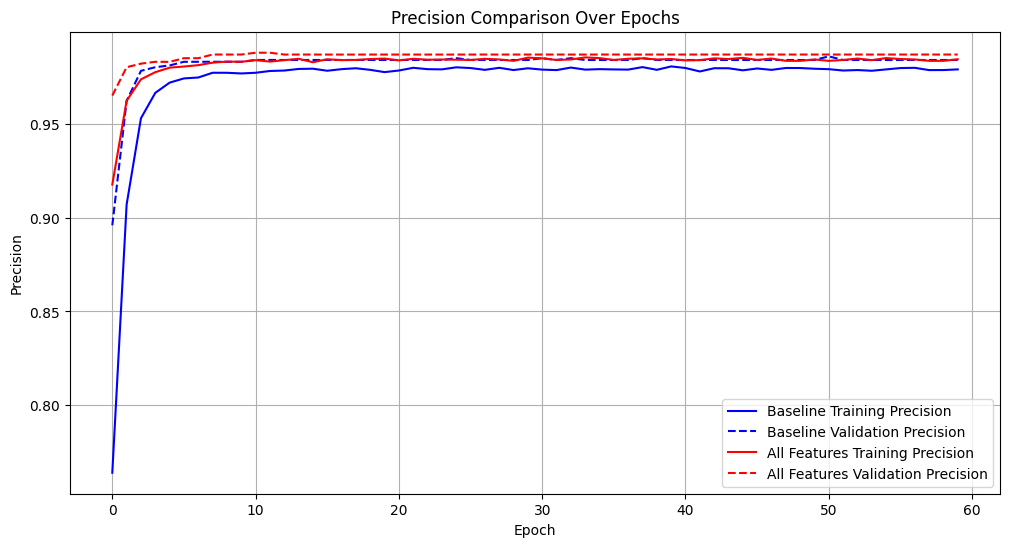

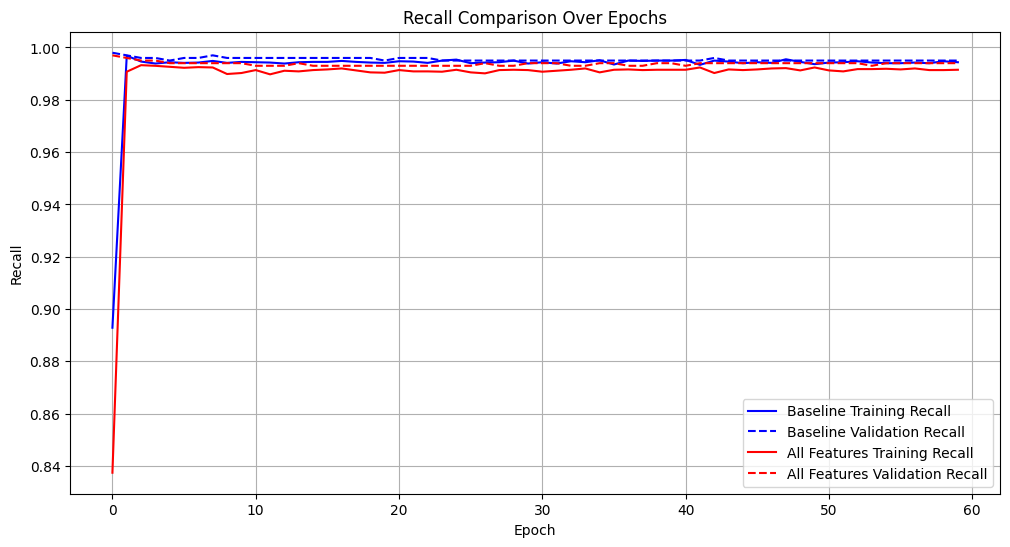

In [124]:
# Plot Precision comparison
plot_metrics_comparison(history, history_all_features, 'precision')

# Plot Recall comparison
plot_metrics_comparison(history, history_all_features, 'recall')

Final get going

In [125]:
# Evaluate test metrics for the model trained using all input features

test_features_dict = {
    feature_name: np.array(test_features[feature_name])
    for feature_name in all_input_features
}

test_results_all_features = model_all_features.evaluate(
    x=test_features_dict,
    y=test_labels,
    verbose=0
)

metric_names = ['loss', 'accuracy', 'precision', 'recall', 'auc']

for i, metric in enumerate(metric_names):
    print(f"Test {metric}: {test_results_all_features[i]:.4f}")

Test loss: 0.0542
Test accuracy: 0.9863
Test precision: 0.9879
Test recall: 0.9869
Test auc: 0.9984


In [126]:
print("\nBaseline Model Test Evaluation:")
baseline_test_features_dict = {
    feature_name: np.array(test_features[feature_name])
    for feature_name in input_features
}
baseline_test_results = model.evaluate(
    x=baseline_test_features_dict,
    y=test_labels,
    verbose=0
)

for i, metric in enumerate(metric_names):
    print(f"Test {metric}: {baseline_test_results[i]:.4f}")



Baseline Model Test Evaluation:
Test loss: 0.0539
Test accuracy: 0.9835
Test precision: 0.9801
Test recall: 0.9899
Test auc: 0.9985


### Final Model Performance Comparison on Test Set

### Saving the Best Performing Model

Based on the test set evaluation, the 'All Features Model' showed a slightly higher accuracy, so we will save this model for future use.

In [128]:
# Save the 'All Features Model' as it performed slightly better in accuracy
model_all_features.save('best_model.keras')

print("Best model (All Features Model) saved as 'best_model.keras'")

Best model (All Features Model) saved as 'best_model.keras'


### ROC Curve Comparison: Baseline vs. All Features Model

This plot visualizes the Receiver Operating Characteristic (ROC) curves for both the baseline and all-features models on the test set, providing a clear comparison of their ability to discriminate between classes across various threshold settings.

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


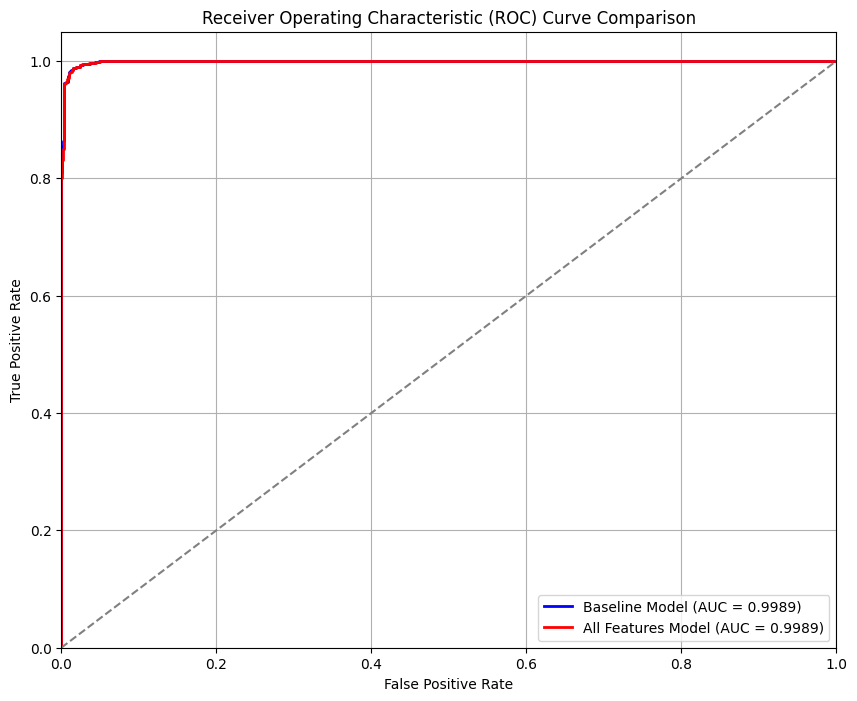

In [129]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# --- Baseline Model ROC Curve ---
# Get predicted probabilities for the positive class from the baseline model
baseline_probabilities = model.predict(baseline_test_features_dict).ravel()

# Calculate ROC curve for baseline model
fpr_baseline, tpr_baseline, _ = roc_curve(test_labels, baseline_probabilities)
auc_baseline = auc(fpr_baseline, tpr_baseline)

# Plot Baseline ROC curve
plt.plot(
    fpr_baseline, tpr_baseline, color='blue', lw=2,
    label=f'Baseline Model (AUC = {auc_baseline:.4f})'
)

# --- All Features Model ROC Curve ---
# Get predicted probabilities for the positive class from the all-features model
all_features_probabilities = model_all_features.predict(test_features_dict_all_features).ravel()

# Calculate ROC curve for all-features model
fpr_all_features, tpr_all_features, _ = roc_curve(test_labels, all_features_probabilities)
auc_all_features = auc(fpr_all_features, tpr_all_features)

# Plot All Features ROC curve
plt.plot(
    fpr_all_features, tpr_all_features, color='red', lw=2,
    label=f'All Features Model (AUC = {auc_all_features:.4f})'
)

# --- Plotting Details ---
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Conclusion of Binary Classification Project

This notebook demonstrates a comprehensive workflow for binary classification using a rice dataset. The key steps and findings are summarized below:

1.  **Data Loading and Preprocessing:**
    *   The `riceClassification.csv` dataset was loaded from Kaggle, accessed via Google Drive.
    *   Relevant features (`Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `Eccentricity`, `ConvexArea`, `Extent`) and the `Class` label were extracted.
    *   The dataset was normalized using Z-score standardization, dynamically handling features with zero standard deviation.
    *   The data was randomized and partitioned into training (80%), validation (10%), and test (10%) sets, ensuring proper stratification.

2.  **Model Definition and Training:**
    *   A flexible `create_model` function was defined to build a Keras sequential model with a hidden layer, ReLU activation, L2 regularization, and Dropout to combat overfitting.
    *   A `train_model` function was implemented, incorporating early stopping based on validation loss to optimize training duration and prevent overfitting.
    *   **Baseline Model:** An initial model was trained using a subset of features (implicitly, all valid features after removing 'Class' and zero-std columns, as defined by `input_features` in cell `Y9uEHj6OQzsC`).
    *   **All Features Model:** A second model was trained using all seven available features (`Eccentricity`, `MajorAxisLength`, `MinorAxisLength`, `Area`, `ConvexArea`, `Perimeter`, `Extent`).

3.  **Model Evaluation and Comparison:**
    *   **Validation Set Evaluation:** Both models were evaluated on the validation set, showing high performance across metrics (accuracy, precision, recall, AUC).
    *   **Confusion Matrix & ROC Curve:** A confusion matrix and ROC curve were generated for the baseline model on the test set, demonstrating strong classification ability (AUC ~0.999).
    *   **Cross-Validation:** Stratified 5-Fold Cross-Validation was performed, revealing stable and consistent performance across all folds for the all-features model, with average accuracy around 98.8% and AUC around 99.8%.
    *   **Test Set Comparison:** A direct comparison of the baseline and all-features models on the unseen test set showed:
        *   The **All Features Model** had slightly higher accuracy (0.9863 vs 0.9835) and precision (0.9879 vs 0.9801).
        *   The **Baseline Model** had slightly higher recall (0.9899 vs 0.9869) and AUC (0.9985 vs 0.9984).
    *   **Visualizations:** Plots were created to compare accuracy, AUC, precision, and recall histories for both models over epochs, and to show cross-validation metrics per fold. A final ROC curve comparison visually reinforced the high performance of both models.

4.  **Model Saving:**
    *   Based on a marginal advantage in accuracy on the test set, the 'All Features Model' was selected as the best performing model and saved as `best_model.keras` for future deployment or analysis.

Overall, the project successfully built and thoroughly evaluated high-performing binary classification models for rice type differentiation, demonstrating robust machine learning practices including data preprocessing, regularization, early stopping, and comprehensive evaluation techniques.

In [127]:
print("\n--- Comparison of Test Metrics ---")
print("Metric        | Baseline Model | All Features Model")
print("---------------------------------------------------")
for i, metric in enumerate(metric_names):
    print(f"{metric.ljust(13)} | {baseline_test_results[i]:<14.4f} | {test_results_all_features[i]:<18.4f}")
print("---------------------------------------------------")

if baseline_test_results[1] > test_results_all_features[1]:
    print("The Baseline Model performed slightly better in accuracy on the test set.")
elif test_results_all_features[1] > baseline_test_results[1]:
    print("The All Features Model performed slightly better in accuracy on the test set.")
else:
    print("Both models performed similarly in accuracy on the test set.")

if baseline_test_results[4] > test_results_all_features[4]:
    print("The Baseline Model performed slightly better in AUC on the test set.")
elif test_results_all_features[4] > baseline_test_results[4]:
    print("The All Features Model performed slightly better in AUC on the test set.")
else:
    print("Both models performed similarly in AUC on the test set.")



--- Comparison of Test Metrics ---
Metric        | Baseline Model | All Features Model
---------------------------------------------------
loss          | 0.0539         | 0.0542            
accuracy      | 0.9835         | 0.9863            
precision     | 0.9801         | 0.9879            
recall        | 0.9899         | 0.9869            
auc           | 0.9985         | 0.9984            
---------------------------------------------------
The All Features Model performed slightly better in accuracy on the test set.
The Baseline Model performed slightly better in AUC on the test set.
